In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from skimage import util
from skimage.io import imread
from skimage.filters import  threshold_triangle, median, sobel
from skimage.measure import label,  regionprops_table, regionprops, regionprops, moments_central
from skimage.morphology import  disk, remove_small_objects, binary_dilation 
from skimage.transform import rotate
from scipy.ndimage import rotate, binary_dilation
from skimage.transform import probabilistic_hough_line
from skimage.draw import line

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [76]:
import numpy as np
from skimage.measure import moments_central

def oriented_central_rect_corners_both_axes(
    mask: np.ndarray,
    width_frac: float = 0.82,
    min_run_frac: float = 0.25,
    bin_size: float = 2.0,
    robust_pct: float = 98.0,
    return_debug: bool = True,
):
    """
    Compute an oriented rectangle around a (nearly) rectangular mask, excluding "necks".
    Unlike simpler versions, this checks for necks along BOTH directions in the rotated
    frame and applies the stronger trimming.

    Steps:
      1) Compute orientation using your verified "angle B"
      2) Rotate foreground coordinates into (u,v) frame about centroid
      3) Compute 1D width profiles in both directions:
           - width_u(v): span in u for each binned v strip
           - width_v(u): span in v for each binned u strip
         Keep strips where width >= width_frac * robust_max_width
         Take the longest contiguous run (>= min_run_frac of total span)
      4) Build a rectangle from the intersection of the chosen u-range and v-range
      5) Rotate 4 corners back to original (x,y) coordinates

    Returns
    -------
    corners_xy : (4,2) float array
        Rectangle corners in (x,y) in original image coords.
    angle_rad : float
        Angle used (radians).
    centroid_xy : (2,) float array
        (x,y) centroid.
    debug : dict (optional)
    """
    ys, xs = np.nonzero(mask)
    if xs.size == 0:
        out = (None, None, None)
        if return_debug:
            return (*out, {"reason": "empty_mask"})
        return out

    # centroid in x,y (col,row)
    cx = xs.mean()
    cy = ys.mean()
    centroid_xy = np.array([cx, cy], dtype=float)

    # --- orientation: your "line B" ---
    mu = moments_central(mask.astype(np.uint8))
    mu20_y = mu[2, 0]   # y^2
    mu02_x = mu[0, 2]   # x^2
    mu11   = mu[1, 1]   # xy
    angle_rad = 0.5 * np.arctan2(2 * mu11, (mu02_x - mu20_y))

    c, s = np.cos(angle_rad), np.sin(angle_rad)

    # rotate coords into aligned frame (u,v) using R^T about centroid
    dx = xs - cx
    dy = ys - cy
    u =  c * dx + s * dy
    v = -s * dx + c * dy

    # ---------- helpers ----------
    def _profile_span(primary, secondary, bin_size):
        """
        For each bin of `primary`, compute min/max of `secondary`.
        Returns bin centers (ints), sec_min, sec_max, widths.
        """
        p_bin = np.floor(primary / bin_size).astype(int)
        p_vals, inv = np.unique(p_bin, return_inverse=True)

        sec_min = np.full(p_vals.shape, np.inf)
        sec_max = np.full(p_vals.shape, -np.inf)
        np.minimum.at(sec_min, inv, secondary)
        np.maximum.at(sec_max, inv, secondary)

        widths = sec_max - sec_min
        return p_vals, sec_min, sec_max, widths

    def _longest_run(p_vals, keep):
        """
        p_vals are sorted ints (bin indices). keep is boolean aligned with p_vals.
        Returns (start, end, length_bins, kept_count).
        """
        best = None
        best_len = 0

        cur_start = None
        cur_end = None

        for i in range(len(p_vals)):
            if not keep[i]:
                if cur_start is not None:
                    L = cur_end - cur_start + 1
                    if L > best_len:
                        best_len = L
                        best = (cur_start, cur_end)
                cur_start = cur_end = None
                continue

            if cur_start is None:
                cur_start = cur_end = p_vals[i]
            else:
                if p_vals[i] == cur_end + 1:
                    cur_end = p_vals[i]
                else:
                    L = cur_end - cur_start + 1
                    if L > best_len:
                        best_len = L
                        best = (cur_start, cur_end)
                    cur_start = cur_end = p_vals[i]

        if cur_start is not None:
            L = cur_end - cur_start + 1
            if L > best_len:
                best_len = L
                best = (cur_start, cur_end)

        if best is None:
            return None, None, 0
        return best[0], best[1], best_len

    def _select_band_along_primary(primary, secondary, name):
        """
        primary/secondary are arrays of same length (points).
        We bin primary, compute width as (secondary_max-secondary_min),
        keep bins >= width_frac * robust_max, choose longest run.
        Returns selected range for primary in *original units* (not bins),
        and debug info.
        """
        p_vals, sec_min, sec_max, widths = _profile_span(primary, secondary, bin_size)

        robust_max = np.percentile(widths, robust_pct) if widths.size else 0.0
        thr = width_frac * robust_max
        keep = widths >= thr

        total_span_bins = int(p_vals.max() - p_vals.min() + 1) if p_vals.size else 0
        min_run_bins = int(np.ceil(min_run_frac * total_span_bins)) if total_span_bins else 0

        start, end, run_len = _longest_run(p_vals, keep)

        # fallback if no run or too short
        used_fallback = False
        if start is None or run_len < min_run_bins:
            used_fallback = True
            start, end = int(p_vals.min()), int(p_vals.max())
            run_len = int(end - start + 1)

        # convert bin range -> original units range
        # bins are floor(primary/bin_size), so bin k covers [k*bin_size, (k+1)*bin_size)
        p_min = start * bin_size
        p_max = (end + 1) * bin_size  # upper edge

        dbg = {
            "name": name,
            "bin_size": float(bin_size),
            "robust_pct": float(robust_pct),
            "width_min": float(widths.min()) if widths.size else None,
            "width_med": float(np.median(widths)) if widths.size else None,
            "width_max": float(widths.max()) if widths.size else None,
            "robust_max": float(robust_max),
            "threshold": float(thr),
            "kept_bins": int(keep.sum()),
            "total_bins": int(keep.size),
            "min_run_bins": int(min_run_bins),
            "chosen_run_bins": (int(start), int(end)),
            "chosen_run_len_bins": int(run_len),
            "used_fallback": bool(used_fallback),
        }
        return (p_min, p_max), dbg

    # ---------- select bands along BOTH directions ----------
    # Band along v (trimming ends along v), width measured in u
    v_range, dbg_v = _select_band_along_primary(v, u, name="band_along_v_using_u_width")
    # Band along u (trimming ends along u), width measured in v
    u_range, dbg_u = _select_band_along_primary(u, v, name="band_along_u_using_v_width")

    # Apply both trims (intersection in the rotated frame)
    vmin, vmax = v_range
    umin, umax = u_range

    # corners in (u,v)
    corners_uv = np.array(
        [[umin, vmin],
         [umax, vmin],
         [umax, vmax],
         [umin, vmax]],
        dtype=float
    )

    # rotate back to original x,y about centroid using R
    x_back = cx + c * corners_uv[:, 0] - s * corners_uv[:, 1]
    y_back = cy + s * corners_uv[:, 0] + c * corners_uv[:, 1]
    corners_xy = np.stack([x_back, y_back], axis=1)

    if not return_debug:
        return corners_xy, angle_rad, centroid_xy

    debug = {
        "angle_deg": float(np.rad2deg(angle_rad)),
        "centroid_xy": (float(cx), float(cy)),
        "params": {
            "width_frac": float(width_frac),
            "min_run_frac": float(min_run_frac),
            "bin_size": float(bin_size),
            "robust_pct": float(robust_pct),
        },
        "band_v": dbg_v,
        "band_u": dbg_u,
        "selected_ranges_rot_frame": {
            "u_range": (float(umin), float(umax)),
            "v_range": (float(vmin), float(vmax)),
        },
    }
    return corners_xy, angle_rad, centroid_xy, debug

In [77]:
def corners_touch_border(corners_xy: np.ndarray, shape, margin=0):
    """
    corners_xy: (4,2) array in (x,y)
    shape: (H,W)
    margin: pixels; treat "within margin of border" as touching
    """
    H, W = shape
    x = corners_xy[:, 0]
    y = corners_xy[:, 1]
    return (
        (x <= margin).any() or (x >= (W - 1 - margin)).any() or
        (y <= margin).any() or (y >= (H - 1 - margin)).any()
    )
    
    
def signed_orientation(region):
    img = region.image.astype(float)
    mu = moments_central(img)
    y20 = mu[2, 0]
    y02 = mu[0, 2]
    y11 = mu[1, 1]
    angle_rad = 0.5 * np.arctan2(2 * y11, y20 - y02)
    return np.rad2deg(angle_rad)

In [81]:
def segment_device(image_paths, image_number, to_plot=True):
    flag = False
    img = imread(image_paths[image_number]).astype(np.float32)

    median_img = median(img, footprint=disk(7))
    sobel_img = sobel(median_img)
    thresh = threshold_triangle(sobel_img)
    binary = sobel_img > thresh

    binary[int(3 * img.shape[0] / 8):int(5 * img.shape[0] / 8),
           int(3 * img.shape[1] / 8):int(5 * img.shape[1] / 8)] = 0

    labels = label(binary)
    data = regionprops_table(labels, binary, properties=("label", "area", "eccentricity"))
    condition = (data["area"] > 100) & (data["eccentricity"] > 0.5)
    labels_to_dilate = util.map_array(labels, data["label"], data["label"] * condition)
    dilated_output = np.zeros_like(labels, dtype=np.uint8)

    for region in regionprops(labels_to_dilate):
        region_label = region.label
        mask = labels_to_dilate == region_label
        angle_to_rotate = signed_orientation(region)  # <-- you already have this
        selem = np.zeros((31, 31), dtype=bool)
        selem[15, :] = 1
        rotated_selem = rotate(selem.astype(float), angle=90 + angle_to_rotate, reshape=False, order=0) > 0.5
        dilated = binary_dilation(mask, structure=rotated_selem)
        dilated_output[dilated] = 255

    final_mask = np.logical_or(dilated_output, binary)

    clean_labels = label(util.invert(final_mask))
    props = regionprops(clean_labels)
    label_sizes = {p.label: p.area for p in props}
    largest_label = max(label_sizes, key=label_sizes.get)
    device_mask = clean_labels == largest_label

    # --- NEW: oriented central rectangle corners (no full-image rotation) ---
    corners, angle_rad, centroid_xy, dbg = oriented_central_rect_corners_both_axes(
        device_mask,
        width_frac=0.82,
        min_run_frac=0.25,
        bin_size=2.0,
        robust_pct=98.0,
        return_debug=True,
    )
    angle_deg = np.rad2deg(angle_rad)
    print(f"Angle (deg): {angle_deg:.2f}")

    # If corners invalid or touches border, do your Hough fix and re-run
    if corners is None or corners_touch_border(corners, device_mask.shape, margin=5):
        flag = True
        print("Device touches border")

        edges = remove_small_objects(labels_to_dilate > 0)

        segs = probabilistic_hough_line(edges, line_length=700, line_gap=600, threshold=50)

        recon = np.zeros_like(edges, dtype=bool)
        for (x0, y0), (x1, y1) in segs:
            rr, cc = line(y0, x0, y1, x1)
            recon[rr, cc] = True

        updated_clean_labels = label(util.invert(np.logical_or(recon, final_mask)))
        props = regionprops(updated_clean_labels)
        label_sizes = {p.label: p.area for p in props}
        largest_label = max(label_sizes, key=label_sizes.get)
        new_device_mask = updated_clean_labels == largest_label

        new_corners, new_angle_rad, new_centroid_xy, new_dbg = oriented_central_rect_corners_both_axes(
            new_device_mask,
            width_frac=0.82,
            min_run_frac=0.25,
            bin_size=2.0,
            robust_pct=98.0,
            return_debug=True,
        )
        new_angle_deg = np.rad2deg(new_angle_rad)
        print(f"Second Angle (deg): {new_angle_deg:.2f}")

    if to_plot:
        print(f"number of cols = {8 + (3 * flag)}")
        fig, ax = plt.subplots(ncols=8 + (3 * flag), figsize=(20, 5))

        ax[0].imshow(img, interpolation="none", cmap="gray")
        ax[1].imshow(sobel_img, interpolation="none", cmap="gray")
        ax[2].imshow(binary, interpolation="none", cmap="gray")
        ax[3].imshow(labels_to_dilate, interpolation="none", cmap="jet")
        ax[4].imshow(final_mask, interpolation="none", cmap="gray")
        ax[5].imshow(device_mask, interpolation="none", cmap="gray")

        ax[6].imshow(img, alpha=0.7, cmap="gray", interpolation="none")
        ax[6].imshow(np.ma.masked_where(device_mask == 0, final_mask), cmap="jet", alpha=0.5, interpolation="none")

        ax[7].imshow(img, alpha=0.7, cmap="gray", interpolation="none")
        ax[7].plot(
            np.r_[corners[:, 0], corners[0, 0]],
            np.r_[corners[:, 1], corners[0, 1]],
            "-r", linewidth=2
        )

        # Optional: show centroid + axis on the overlay panel
        cx, cy = centroid_xy
        ax[7].plot(cx, cy, "xg", markersize=10, mew=2)
        L = 150
        dx = L * np.cos(angle_rad)
        dy = L * np.sin(angle_rad)
        ax[7].plot([cx - dx, cx + dx], [cy - dy, cy + dy], "-g", lw=2)

        if flag:
            ax[8].imshow(edges, cmap="gray")
            ax[9].imshow(np.logical_or(recon, final_mask), cmap="gray")
            ax[10].imshow(img, alpha=0.7, interpolation="none", cmap="gray")
            ax[10].plot(
                np.r_[new_corners[:, 0], new_corners[0, 0]],
                np.r_[new_corners[:, 1], new_corners[0, 1]],
                "-r", linewidth=2
            )

            # Optional: centroid + axis for second pass
            ncx, ncy = new_centroid_xy
            ax[10].plot(ncx, ncy, "xg", markersize=10, mew=2)
            ndx = L * np.cos(new_angle_rad)
            ndy = L * np.sin(new_angle_rad)
            ax[10].plot([ncx - ndx, ncx + ndx], [ncy - ndy, ncy + ndy], "-g", lw=2)

        titles = [
            "Original Image", "Sobel", "Binarised", "Labels to Dilate",
            "Final Mask", "Clean Mask", "Clean Labels", "Overlay",
            "Edges", "Reconstructed", "Final"
        ]

        for i, axis in enumerate(ax):
            ax[i].axis("off")
            if i < len(titles):
                ax[i].set_title(titles[i])

        plt.savefig(f"device_segmentation_conventional_methods_output_{image_number}.pdf", transparent=True)
        plt.show()

    # Preserve your original return semantics
    if flag:
        return (final_mask, edges, np.logical_or(recon, final_mask))
    else:
        return (final_mask, None, None)

411
Processing image 1
Angle (deg): 88.19
number of cols = 8


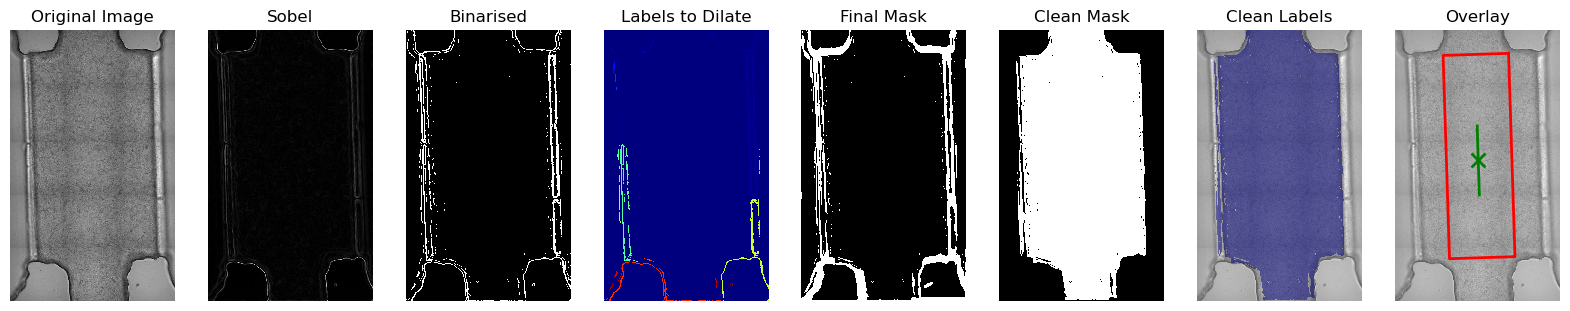

Processing image 3
Angle (deg): -89.96
number of cols = 8


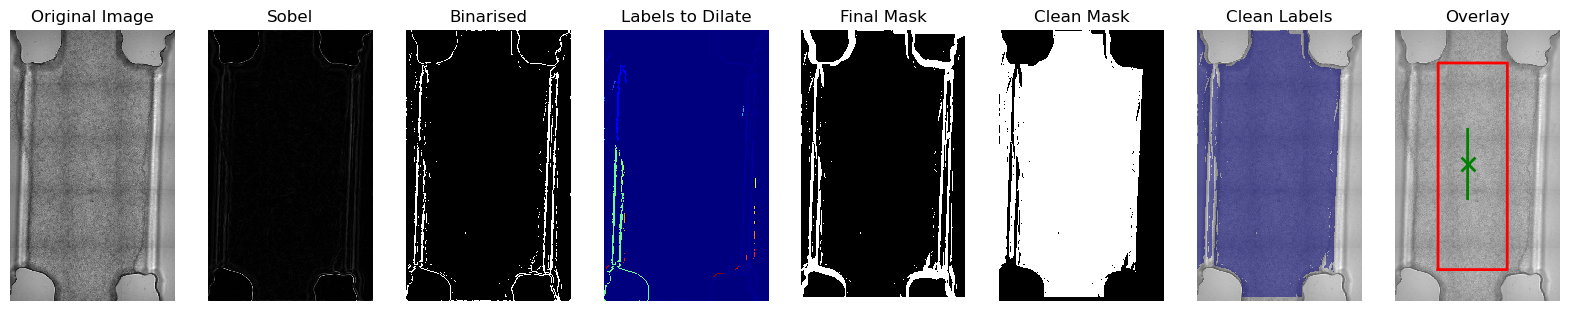

Processing image 5
Angle (deg): -88.52
number of cols = 8


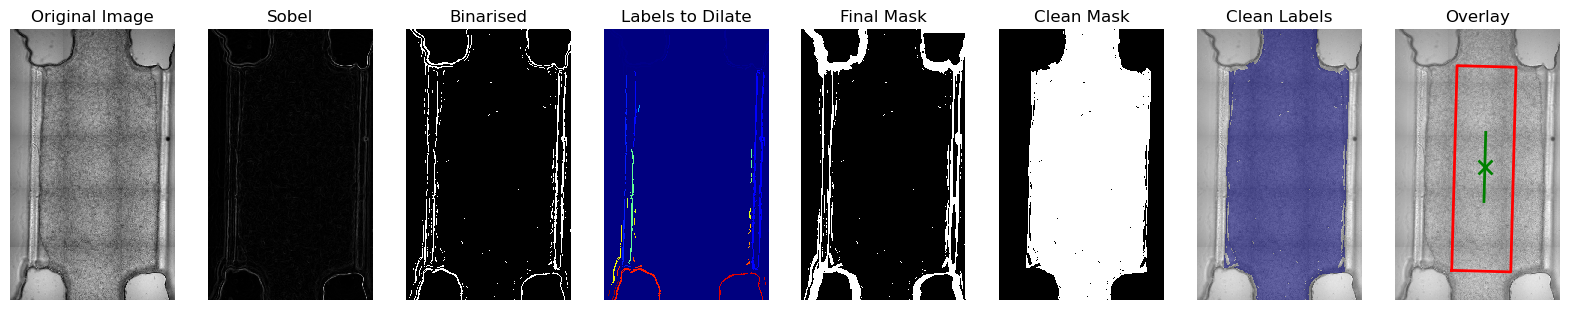

Processing image 7
Angle (deg): -89.21
number of cols = 8


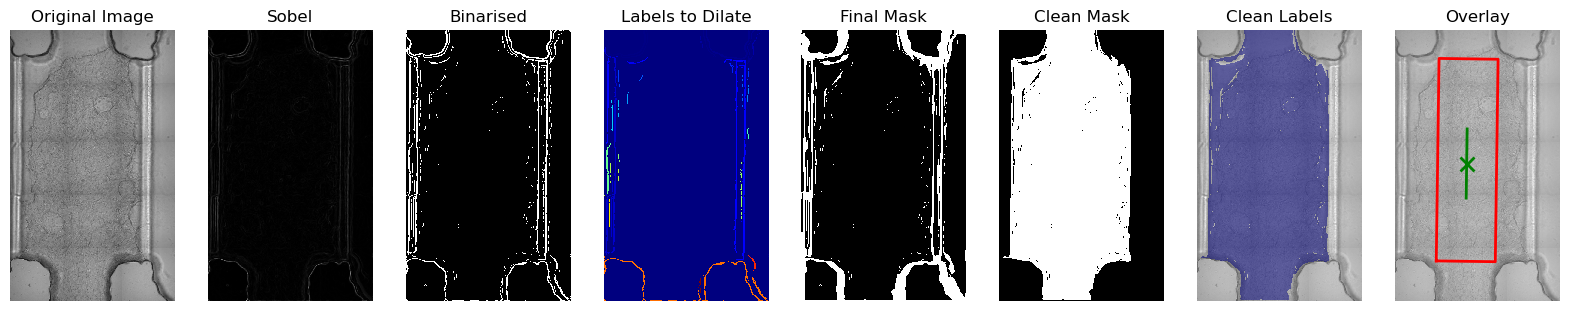

Processing image 15


In [ ]:
unseen_image_folder = Path(r"Z:\Bel\Vascumap_Example_Lifs\training_data\downsampled_4\in_focus_each_point")
tif_files = list(unseen_image_folder.glob("*.tif"))
print(len(tif_files))

for j in [1,3,5,7,15,25,120,90,172,221,275,301]:
    print(f"Processing image {j}")
    segment_device(tif_files, j)

Angle (deg): 89.26
Device touches border
Second Angle (deg): -85.42
number of cols = 11


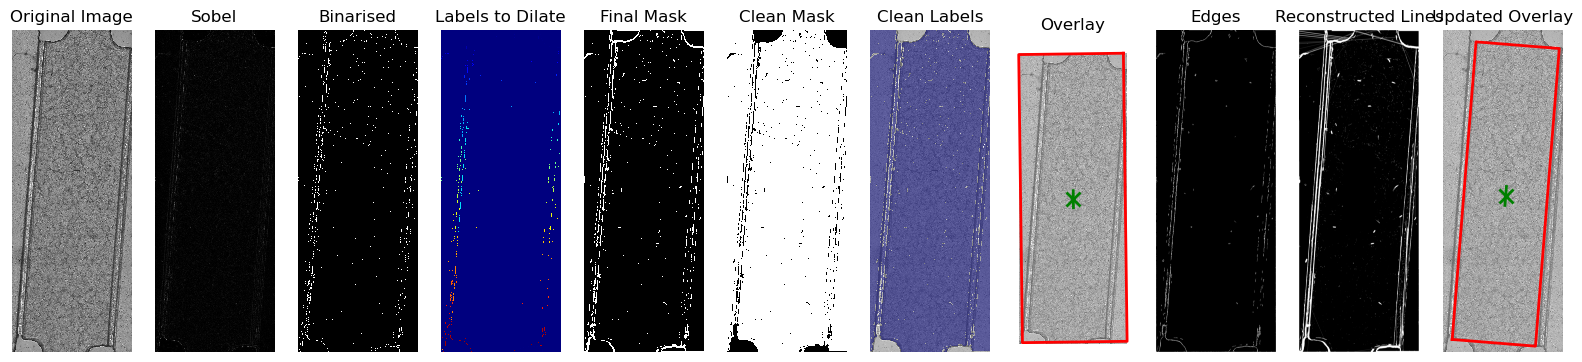

In [ ]:
final_mask, edges, mask = segment_device(tif_files, 15)

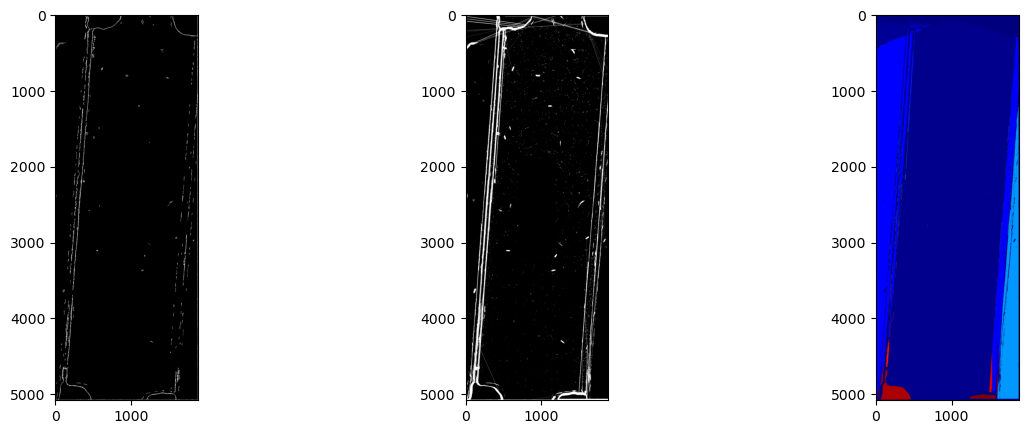

In [24]:

segs = probabilistic_hough_line(edges, line_length=700, line_gap=600, threshold=50)

recon = np.zeros_like(edges, dtype=bool)
for (x0,y0), (x1,y1) in segs:
    rr, cc = line(y0, x0, y1, x1)
    recon[rr, cc] = True
updated_clean_labels = label(util.invert(np.logical_or(recon,final_mask)))
fig, ax = plt.subplots(ncols=3, figsize=(15,5))
ax[0].imshow(edges, cmap='gray')
ax[1].imshow(np.logical_or(recon,final_mask), cmap='gray')
ax[2].imshow(updated_clean_labels, cmap="jet")

In [25]:
updated_clean_labels = label(util.invert(np.logical_or(recon,final_mask)))
props = regionprops(updated_clean_labels)

label_sizes = {p.label: p.area for p in props}
largest_label = max(label_sizes, key=label_sizes.get)
new_device_mask = updated_clean_labels == largest_label
mu = moments_central(new_device_mask)
y20 = mu[2, 0]
y02 = mu[0, 2]
y11 = mu[1, 1]
angle_rad = 0.5 * np.arctan2(2 * y11, y20 - y02)
angle_deg = np.rad2deg(angle_rad)

mask dtype: bool
mask shape: (5083, 1884)
foreground pixels: 6372232
mu[2,0] (y^2): 12429549182237.086
mu[0,2] (x^2): 979641925508.5332
mu[1,1] (xy) : -911139017046.5469
angleA deg: -4.521454151797727
angleB deg: -85.47854584820227
regionprops.orientation deg: -4.521454151797734
regionprops.centroid (row,col): (np.float64(2608.889479855724), np.float64(997.5064300860358))


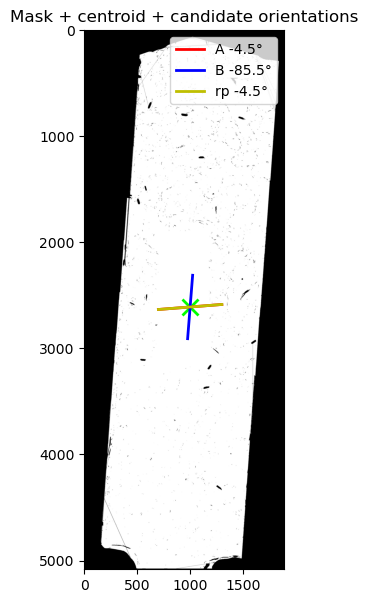

In [ ]:

new_device_mask = (updated_clean_labels == largest_label)

# ---- sanity check: is the mask empty?
print("mask dtype:", new_device_mask.dtype)
print("mask shape:", new_device_mask.shape)
print("foreground pixels:", int(new_device_mask.sum()))
if new_device_mask.sum() == 0:
    raise ValueError("Mask is empty (no True pixels). largest_label may be wrong.")

# ---- moments
mu = moments_central(new_device_mask.astype(np.uint8))
mu20_y = mu[2, 0]   # along rows (y)
mu02_x = mu[0, 2]   # along cols (x)
mu11   = mu[1, 1]

angleA = 0.5 * np.arctan2(2 * mu11, (mu20_y - mu02_x))
angleB = 0.5 * np.arctan2(2 * mu11, (mu02_x - mu20_y))

print("mu[2,0] (y^2):", mu20_y)
print("mu[0,2] (x^2):", mu02_x)
print("mu[1,1] (xy) :", mu11)
print("angleA deg:", np.rad2deg(angleA))
print("angleB deg:", np.rad2deg(angleB))

# ---- regionprops reference (often easiest to trust)
lab = label(new_device_mask)
rp = regionprops(lab)[0]
theta_rp = rp.orientation  # radians
print("regionprops.orientation deg:", np.rad2deg(theta_rp))
print("regionprops.centroid (row,col):", rp.centroid)

# centroid in x,y
cy, cx = rp.centroid  # (row, col)
L = 300  # half-length of line

def draw_axis(ax, theta, color, text):
    dx = L * np.cos(theta)
    dy = L * np.sin(theta)
    ax.plot([cx - dx, cx + dx], [cy - dy, cy + dy], color, lw=2, label=text)

# ---- plot
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(new_device_mask, cmap="gray")
ax.plot(cx, cy, marker="x", color="lime", markersize=12, mew=2)

draw_axis(ax, angleA, "r", f"A {np.rad2deg(angleA):.1f}°")
draw_axis(ax, angleB, "b", f"B {np.rad2deg(angleB):.1f}°")
draw_axis(ax, theta_rp, "y", f"rp {np.rad2deg(theta_rp):.1f}°")

ax.set_title("Mask + centroid + candidate orientations")
ax.legend()
plt.show()

In [74]:
import numpy as np
from skimage.measure import moments_central

def oriented_central_rect_corners_both_axes(
    mask: np.ndarray,
    width_frac: float = 0.82,
    min_run_frac: float = 0.25,
    bin_size: float = 2.0,
    robust_pct: float = 98.0,
    return_debug: bool = True,
):
    """
    Compute an oriented rectangle around a (nearly) rectangular mask, excluding "necks".
    Unlike simpler versions, this checks for necks along BOTH directions in the rotated
    frame and applies the stronger trimming.

    Steps:
      1) Compute orientation using your verified "angle B"
      2) Rotate foreground coordinates into (u,v) frame about centroid
      3) Compute 1D width profiles in both directions:
           - width_u(v): span in u for each binned v strip
           - width_v(u): span in v for each binned u strip
         Keep strips where width >= width_frac * robust_max_width
         Take the longest contiguous run (>= min_run_frac of total span)
      4) Build a rectangle from the intersection of the chosen u-range and v-range
      5) Rotate 4 corners back to original (x,y) coordinates

    Returns
    -------
    corners_xy : (4,2) float array
        Rectangle corners in (x,y) in original image coords.
    angle_rad : float
        Angle used (radians).
    centroid_xy : (2,) float array
        (x,y) centroid.
    debug : dict (optional)
    """
    ys, xs = np.nonzero(mask)
    if xs.size == 0:
        out = (None, None, None)
        if return_debug:
            return (*out, {"reason": "empty_mask"})
        return out

    # centroid in x,y (col,row)
    cx = xs.mean()
    cy = ys.mean()
    centroid_xy = np.array([cx, cy], dtype=float)

    # --- orientation: your "line B" ---
    mu = moments_central(mask.astype(np.uint8))
    mu20_y = mu[2, 0]   # y^2
    mu02_x = mu[0, 2]   # x^2
    mu11   = mu[1, 1]   # xy
    angle_rad = 0.5 * np.arctan2(2 * mu11, (mu02_x - mu20_y))

    c, s = np.cos(angle_rad), np.sin(angle_rad)

    # rotate coords into aligned frame (u,v) using R^T about centroid
    dx = xs - cx
    dy = ys - cy
    u =  c * dx + s * dy
    v = -s * dx + c * dy

    # ---------- helpers ----------
    def _profile_span(primary, secondary, bin_size):
        """
        For each bin of `primary`, compute min/max of `secondary`.
        Returns bin centers (ints), sec_min, sec_max, widths.
        """
        p_bin = np.floor(primary / bin_size).astype(int)
        p_vals, inv = np.unique(p_bin, return_inverse=True)

        sec_min = np.full(p_vals.shape, np.inf)
        sec_max = np.full(p_vals.shape, -np.inf)
        np.minimum.at(sec_min, inv, secondary)
        np.maximum.at(sec_max, inv, secondary)

        widths = sec_max - sec_min
        return p_vals, sec_min, sec_max, widths

    def _longest_run(p_vals, keep):
        """
        p_vals are sorted ints (bin indices). keep is boolean aligned with p_vals.
        Returns (start, end, length_bins, kept_count).
        """
        best = None
        best_len = 0

        cur_start = None
        cur_end = None

        for i in range(len(p_vals)):
            if not keep[i]:
                if cur_start is not None:
                    L = cur_end - cur_start + 1
                    if L > best_len:
                        best_len = L
                        best = (cur_start, cur_end)
                cur_start = cur_end = None
                continue

            if cur_start is None:
                cur_start = cur_end = p_vals[i]
            else:
                if p_vals[i] == cur_end + 1:
                    cur_end = p_vals[i]
                else:
                    L = cur_end - cur_start + 1
                    if L > best_len:
                        best_len = L
                        best = (cur_start, cur_end)
                    cur_start = cur_end = p_vals[i]

        if cur_start is not None:
            L = cur_end - cur_start + 1
            if L > best_len:
                best_len = L
                best = (cur_start, cur_end)

        if best is None:
            return None, None, 0
        return best[0], best[1], best_len

    def _select_band_along_primary(primary, secondary, name):
        """
        primary/secondary are arrays of same length (points).
        We bin primary, compute width as (secondary_max-secondary_min),
        keep bins >= width_frac * robust_max, choose longest run.
        Returns selected range for primary in *original units* (not bins),
        and debug info.
        """
        p_vals, sec_min, sec_max, widths = _profile_span(primary, secondary, bin_size)

        robust_max = np.percentile(widths, robust_pct) if widths.size else 0.0
        thr = width_frac * robust_max
        keep = widths >= thr

        total_span_bins = int(p_vals.max() - p_vals.min() + 1) if p_vals.size else 0
        min_run_bins = int(np.ceil(min_run_frac * total_span_bins)) if total_span_bins else 0

        start, end, run_len = _longest_run(p_vals, keep)

        # fallback if no run or too short
        used_fallback = False
        if start is None or run_len < min_run_bins:
            used_fallback = True
            start, end = int(p_vals.min()), int(p_vals.max())
            run_len = int(end - start + 1)

        # convert bin range -> original units range
        # bins are floor(primary/bin_size), so bin k covers [k*bin_size, (k+1)*bin_size)
        p_min = start * bin_size
        p_max = (end + 1) * bin_size  # upper edge

        dbg = {
            "name": name,
            "bin_size": float(bin_size),
            "robust_pct": float(robust_pct),
            "width_min": float(widths.min()) if widths.size else None,
            "width_med": float(np.median(widths)) if widths.size else None,
            "width_max": float(widths.max()) if widths.size else None,
            "robust_max": float(robust_max),
            "threshold": float(thr),
            "kept_bins": int(keep.sum()),
            "total_bins": int(keep.size),
            "min_run_bins": int(min_run_bins),
            "chosen_run_bins": (int(start), int(end)),
            "chosen_run_len_bins": int(run_len),
            "used_fallback": bool(used_fallback),
        }
        return (p_min, p_max), dbg

    # ---------- select bands along BOTH directions ----------
    # Band along v (trimming ends along v), width measured in u
    v_range, dbg_v = _select_band_along_primary(v, u, name="band_along_v_using_u_width")
    # Band along u (trimming ends along u), width measured in v
    u_range, dbg_u = _select_band_along_primary(u, v, name="band_along_u_using_v_width")

    # Apply both trims (intersection in the rotated frame)
    vmin, vmax = v_range
    umin, umax = u_range

    # corners in (u,v)
    corners_uv = np.array(
        [[umin, vmin],
         [umax, vmin],
         [umax, vmax],
         [umin, vmax]],
        dtype=float
    )

    # rotate back to original x,y about centroid using R
    x_back = cx + c * corners_uv[:, 0] - s * corners_uv[:, 1]
    y_back = cy + s * corners_uv[:, 0] + c * corners_uv[:, 1]
    corners_xy = np.stack([x_back, y_back], axis=1)

    if not return_debug:
        return corners_xy, angle_rad, centroid_xy

    debug = {
        "angle_deg": float(np.rad2deg(angle_rad)),
        "centroid_xy": (float(cx), float(cy)),
        "params": {
            "width_frac": float(width_frac),
            "min_run_frac": float(min_run_frac),
            "bin_size": float(bin_size),
            "robust_pct": float(robust_pct),
        },
        "band_v": dbg_v,
        "band_u": dbg_u,
        "selected_ranges_rot_frame": {
            "u_range": (float(umin), float(umax)),
            "v_range": (float(vmin), float(vmax)),
        },
    }
    return corners_xy, angle_rad, centroid_xy, debug

{'name': 'band_along_v_using_u_width', 'bin_size': 2.0, 'robust_pct': 98.0, 'width_min': 107.37649514821794, 'width_med': 4887.1882434949475, 'width_max': 5028.774256265448, 'robust_max': 5023.710984458018, 'threshold': 4119.443007255574, 'kept_bins': 660, 'total_bins': 675, 'min_run_bins': 169, 'chosen_run_bins': (-331, 328), 'chosen_run_len_bins': 660, 'used_fallback': False}
{'name': 'band_along_u_using_v_width', 'bin_size': 2.0, 'robust_pct': 98.0, 'width_min': 0.9968878851830141, 'width_med': 1329.2326803080912, 'width_max': 1342.2710551969853, 'robust_max': 1337.2866157710703, 'threshold': 1096.5750249322775, 'kept_bins': 2357, 'total_bins': 2521, 'min_run_bins': 631, 'chosen_run_bins': (-1167, 1189), 'chosen_run_len_bins': 2357, 'used_fallback': False}


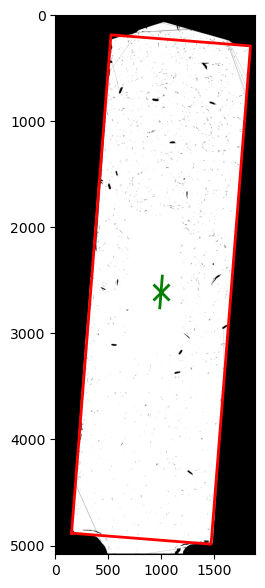

In [75]:
import numpy as np
import matplotlib.pyplot as plt

new_device_mask = (updated_clean_labels == largest_label)

corners_xy, angle_rad, centroid_xy, dbg = oriented_central_rect_corners_both_axes(
    new_device_mask,
    width_frac=0.82,
    min_run_frac=0.25,
    bin_size=2.0,
    robust_pct=98.0,
)

print(dbg["band_v"])
print(dbg["band_u"])

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(new_device_mask, cmap="gray")

# centroid
cx, cy = centroid_xy
ax.plot(cx, cy, "xg", markersize=12, mew=2)

# principal axis line
L = 150
dx = L * np.cos(angle_rad)
dy = L * np.sin(angle_rad)
ax.plot([cx - dx, cx + dx], [cy - dy, cy + dy], "-g", lw=2)

# rectangle
poly = np.vstack([corners_xy, corners_xy[0]])
ax.plot(poly[:, 0], poly[:, 1], "-r", lw=2)

plt.show()